In [9]:
#want to visualize the reconstruction error better
import utils
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [10]:
MODEL_NAME = '2d-full-relu-wide'

DATA_PATH = '../../initialSingleCellDf-channel-20220916-MW_018-001.h5'
ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
CELL_TYPE='OT-1'
CONCENTRATIONS = ['10pM','1nM','1uM']

GROUP_SIZE = 5

MARKER_RANGE = (-1,1)

In [11]:
X,Y = utils.load_data(DATA_PATH, CELL_TYPE, ANTIGENS, GROUP_SIZE, MARKER_RANGE)

In [12]:
print(X.shape)

(609574, 26)


In [13]:
model_path = f'./checkpoints/best_model_{MODEL_NAME}.h5'
model = tf.keras.models.load_model(model_path)
reconstruction = model.predict(X)

   39/19050 [..............................] - ETA: 50s 

2023-12-17 23:02:50.458066: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


19050/19050 [==============================] - 47s 2ms/step


In [14]:
diff = X - reconstruction
mse = np.square(diff)
mse = np.mean(mse, axis=0)
abs_error = np.abs(diff)
abs_error = np.mean(abs_error, axis=0)

In [15]:
#get the column names of the dataframe
column_names =['FSC-A', 'SSC-A', 'CD25', 'CD38', 'Granzyme B', 'CD2', 'CD27', 'CD45RA', 'CD4', 'CD86', 'CXCR6', 'CD5', 'CD62L', 'OX40', 'PD-L1', 'TBet', 'CD126', 'Proliferation', 'ICOS', 'IRF8', 'CD19', 'MHC-II', 'CD45', 'CD44', 'CX3CR1', 'CD8a']
print(column_names)

['FSC-A', 'SSC-A', 'CD25', 'CD38', 'Granzyme B', 'CD2', 'CD27', 'CD45RA', 'CD4', 'CD86', 'CXCR6', 'CD5', 'CD62L', 'OX40', 'PD-L1', 'TBet', 'CD126', 'Proliferation', 'ICOS', 'IRF8', 'CD19', 'MHC-II', 'CD45', 'CD44', 'CX3CR1', 'CD8a']


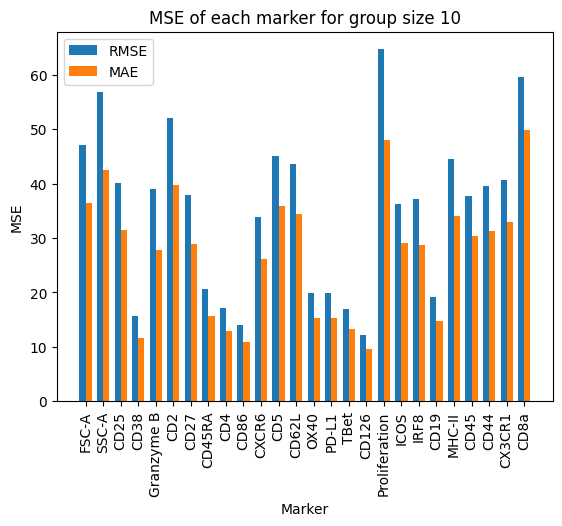

In [19]:
fig, ax = plt.subplots()
bar_width = 0.35  # Adjust this value to control the width of the bars

# Calculate the x positions for the bars
x = np.arange(len(column_names))

# Plot the RMSE bars
ax.bar(x, np.sqrt(mse)*1023/2, width=bar_width, label='RMSE')

# Plot the MAE bars
ax.bar(x + bar_width, abs_error*1023/2, width=bar_width, label='MAE')

ax.set_ylabel('MSE')
ax.set_xlabel('Marker')
ax.set_title('MSE of each marker for group size '+str(GROUP_SIZE))

# Set the x-axis tick positions and labels
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(column_names, rotation=90)

plt.legend()
plt.show()